In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
np.random.seed(42)
# 난수 고정으로 재현성 확보

In [2]:
#  시각화/통계/모델 관련 라이브러리 임포트

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer  # 열 단위 전처리 파이프라인
from sklearn.pipeline import Pipeline  # 전체 파이프라인 구성 도구
from sklearn.linear_model import LogisticRegression  # 이진 분류용 로지스틱 회귀 모델
from sklearn.metrics import (  # 성능 평가 지표 함수들 임포트
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.inspection import permutation_importance  # 퍼뮤테이션 특성 중요도 계산
import joblib  # 모델 저장/로딩을 위한 직렬화 도구

In [4]:
# 고객 이탈(Churn) "합성 데이터" 생성
# >> 실제 Telco Churn 유사 스키마(수치+범주 혼합)

N = 5000  # 샘플 수
# 수치형 특징 생성: 재직기간(개월), 월요금, 총요금, 고객지원문의 횟수
tenure = np.random.randint(0, 72, size=N)  # 0~71개월 사이 임의 재직기간
monthly_charges = np.round(np.random.normal(60, 15, size=N), 2)
# 평균 60, 표준편차 15의 월요금
monthly_charges = np.clip(monthly_charges, 5, 200)
# 월요금 이상치 클리핑(5~200) >> 정규분포에서 극단적인 값(낮거나 높은 값) 조정
total_charges = np.round(monthly_charges * (tenure + np.random.normal(0.0, 1.0, size=N)), 2)
# 총요금 근사치(월요금 * 재직기간)
support_calls = np.random.poisson(lam=1.8, size=N)  # 고객센터 문의 횟수(포아송 분포)
# 포아송 분포: 일정 기간에 특정사건이 발생하는 횟수을 모델링
# 평균적으로 고객 1명 당 1.8회 정도 문의한다는 기존 통계 정보 활용

# 범주형 특징 생성: 계약형태, 인터넷, 기가옵션, 부가서비스, 결제수단
contract_type = np.random.choice(["month-to-month", "one-year", "two-year"], size=N, p=[0.6, 0.25, 0.15])
# 계약형태p=[0.6, 0.25, 0.15] 월 단위 계약이 60%로 제일 많도록 설정

has_internet = np.random.choice(["yes", "no"], size=N, p=[0.8, 0.2])  # 인터넷 가입 여부
has_giga = np.where((has_internet == "yes") & (np.random.rand(N) < 0.3), "yes", "no")
# 기가옵션(인터넷 가입자 중 일부)
add_on = np.random.choice(["none", "security", "streaming", "both"], size=N, p=[0.4, 0.25, 0.25, 0.10])
# 부가서비스
payment_method = np.random.choice(["credit_card", "bank_transfer", "e_check", "cash"], size=N, p=[0.35, 0.25, 0.30, 0.10])
# 결제수단

# 타깃(이탈 여부) 생성 규칙: 특정 패턴에 의해 확률적으로 이탈 발생
# - 단기 계약(month-to-month), 높은 월요금, 잦은 고객센터 문의, e_check 사용, 인터넷 없음/품질 이슈 등은 이탈 확률을 높임
logit = (
    -2.0  # 기준 절편(이탈 기본 난이도) bias
    + 0.03 * (70 - tenure)  # 재직기간이 짧을수록 이탈↑
    + 0.015 * (monthly_charges - 60)  # 월요금이 높을수록 이탈↑
    + 0.25 * support_calls  # 고객센터 문의 많을수록 이탈↑
    + np.where(contract_type == "month-to-month", 0.8, 0.0)  # 단기 계약 이탈↑
    + np.where(payment_method == "e_check", 0.5, 0.0)  # e_check 이탈↑ (가상의 가정)
    + np.where(has_internet == "no", 0.3, 0.0)  # 인터넷 미가입자는 서비스 가치↓ → 이탈↑
    + np.where((has_internet == "yes") & (has_giga == "no") & (monthly_charges > 80), 0.25, 0.0)
    # 고요금+기가 미사용 이탈↑
)
prob = 1 / (1 + np.exp(-logit))  # 로지스틱 변환으로 이탈 확률 계산(logit 크면 확률이 1에 가까워 져요)
churn = np.random.binomial(1, prob, size=N)  # 베르누이 샘플링으로 0/1 타깃 생성
# 이항 분포 (1, 1-p) >>> 1(이탈), 1-prob 0(유지)

In [6]:
# 데이터프레임 구성
df = pd.DataFrame({  # pandas DataFrame으로 합치기
    "tenure": tenure,
    "monthly_charges": monthly_charges,
    "total_charges": total_charges,
    "support_calls": support_calls,
    "contract_type": contract_type,
    "has_internet": has_internet,
    "has_giga": has_giga,
    "add_on": add_on,
    "payment_method": payment_method,
    "churn": churn
})

In [7]:
df.head()

,tenure,monthly_charges,total_charges,support_calls,contract_type,has_internet,has_giga,add_on,payment_method,churn
0,51,74.67,3819.56,0,month-to-month,yes,no,streaming,bank_transfer,0
1,14,28.42,353.79,3,month-to-month,yes,no,none,credit_card,1
2,71,77.30,5659.47,1,month-to-month,yes,no,none,bank_transfer,0
3,60,80.80,4739.11,4,month-to-month,yes,no,both,credit_card,1
4,20,55.47,1091.55,2,month-to-month,yes,yes,none,cash,0


In [11]:
# 데이터 분할(학습/평가) stratify 타겟 비율 유지

X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test =\
train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [12]:
# 전처리 파이프라인 구성
#    - 수치형: 표준화(StandardScaler)
#    - 범주형: 원-핫 인코딩(OneHotEncoder)
#    - 모델: LogisticRegression(class_weight="balanced")

numeric_features = ["tenure", "monthly_charges", "total_charges", "support_calls"]  # 수치형 열 목록
categorical_features = ["contract_type", "has_internet", "has_giga", "add_on", "payment_method"]  # 범주형 열 목록

In [13]:
# 수치형 데이터 전처리 파이프라인 구축
numeric_transformer = Pipeline(steps=[('scaler',StandardScaler())])

In [14]:
# 범주형 데이터 전처리 파이프라인 구축
categorical_transformer = OneHotEncoder(handle_unknown ='ignore', sparse_output=False)
# 미지의 범주 무시, 밀집배열 출력

In [16]:
preprocessor =\
ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),       # 수치형 처리
        ('cat', categorical_transformer, categorical_features)# 범주형 처리
    ],
    remainder='drop' # 지정되지 않은 열은 제거 cf.remainder='passthrough' 그대로 전달(유지)
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['tenure', 'monthly_charges', 'total_charges',
                                  'support_calls']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['contract_type', 'has_internet', 'has_giga',
                                  'add_on', 'payment_method'])])


In [17]:
# 분류 모델 정의

clf = LogisticRegression(class_weight="balanced",
                   # 이탈/비이탈 불균형 자동 가중치로 보정 >> 소수 클래스(이탈)에 높은 가중치 부여
                   max_iter = 200,
                   solver='liblinear', # 소규모/회소 특성에 안정적인 solver
                   random_state=42
)


In [18]:
pipe = Pipeline(steps=[
    ('preprocess', preprocessor), # 전처리 단계
    ('model', clf)                # 분류 모델 단계
])

In [19]:
# 모델 학습
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'monthly_charges',
                                                   'total_charges',
                                                   'support_calls']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['contract_type',
                                                   'has_internet', 'has_giga',
                                                   'add_on',
                                                   'payment_method'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=200,
                                    random_state=42, solver='liblinear'))])

In [21]:
# 기본 임계값 (0.5) 평가

y_proba = pipe.predict_proba(X_test)[:, 1] # 이탈(1) 클래스 예측확률
y_pred = (y_proba >= 0.5).astype(int)      # 기본 임계값(0.5) 이진 확률

print(y_proba[:5])
print()
print(y_pred[:5])

[0.78904889 0.84430827 0.28513085 0.60109209 0.10508769]

[1 1 0 1 0]


In [22]:
acc = accuracy_score(y_test, y_pred)  # 정확도 계산
prec = precision_score(y_test, y_pred, zero_division=0)  # 정밀도 계산
rec = recall_score(y_test, y_pred, zero_division=0)  # 재현율 계산
f1 = f1_score(y_test, y_pred, zero_division=0)  # F1 점수 계산
auc = roc_auc_score(y_test, y_proba)  # ROC-AUC 계산

print("=== 기본 임계값(0.5) 평가 ===")  # 출력 제목
print(f"Accuracy:  {acc:.4f}")  # 정확도 출력
print(f"Precision: {prec:.4f}")  # 정밀도 출력
print(f"Recall:    {rec:.4f}")  # 재현율 출력
print(f"F1-score:  {f1:.4f}")  # F1 점수 출력
print(f"ROC-AUC:   {auc:.4f}\n")  # ROC-AUC 출력

print("=== 분류 보고서(Classification Report) ===")  # 상세 보고서 제목
print(classification_report(y_test, y_pred, digits=4))  # 정밀도/재현율/F1 등 클래스별 상세

=== 기본 임계값(0.5) 평가 ===
Accuracy:  0.6400
Precision: 0.6742
Recall:    0.6544
F1-score:  0.6642
ROC-AUC:   0.7198

=== 분류 보고서(Classification Report) ===
              precision    recall  f1-score   support

           0     0.6017    0.6228    0.6121       456
           1     0.6742    0.6544    0.6642       544

    accuracy                         0.6400      1000
   macro avg     0.6380    0.6386    0.6381      1000
weighted avg     0.6412    0.6400    0.6404      1000



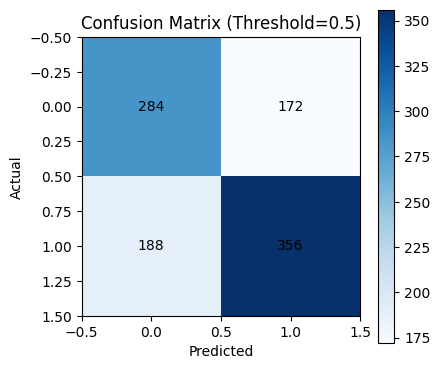

In [23]:
# 혼동행렬 시각화 (matplotlib 기본)
cm = confusion_matrix(y_test, y_pred)  # 혼동행렬 계산

fig, ax = plt.subplots(figsize=(4.5, 4))  # 그림/축 생성
im = ax.imshow(cm, cmap="Blues")  # 행렬 이미지 표시(컬러맵: Blues)
ax.set_title("Confusion Matrix (Threshold=0.5)")  # 제목
ax.set_xlabel("Predicted")  # x축 라벨
ax.set_ylabel("Actual")  # y축 라벨

for (i, j), v in np.ndenumerate(cm):  # 각 셀에 값 표기
    ax.text(j, i, str(v), ha="center", va="center")  # 중앙 정렬 텍스트
plt.colorbar(im)  # 컬러바 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()  # 그래프 출력

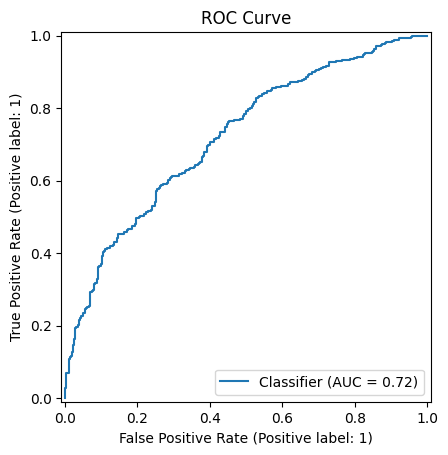

In [24]:
# ROC 곡선 시각화
RocCurveDisplay.from_predictions(y_test, y_proba)  # 예측 기반 ROC 디스플레이
plt.title("ROC Curve")
plt.show()

In [25]:
# 임계값 최적화 (F1 기준으로 베스트 임계값 탐색)

thresholds = np.linspace(0.1, 0.9, 81)  # 0.1~0.9 범위에서 0.01 간격 후보 임계값

best_thr, best_f1 = 0.5, f1  # 초기값(기본 임계값 성능)
for thr in thresholds:  # 모든 후보 임계값 순회
    y_hat = (y_proba >= thr).astype(int)  # 임계값 적용 예측
    f1_tmp = f1_score(y_test, y_hat, zero_division=0)  # F1 계산
    if f1_tmp > best_f1:  # 더 좋은 F1이면 갱신
        best_f1 = f1_tmp  # 최고 F1 갱신
        best_thr = thr  # 최고 임계값 갱신

print(f"\n=== 임계값 최적화 결과 (기준: F1) ===")  # 출력 제목
print(f"Best Threshold: {best_thr:.2f}, Best F1: {best_f1:.4f}")  # 최적 임계값/성능 출력


=== 임계값 최적화 결과 (기준: F1) ===
Best Threshold: 0.38, Best F1: 0.7323


In [26]:
# 최적 임계값 재평가
y_pred_opt = (y_proba >= best_thr).astype(int)  # 최적 임계값 적용 예측

acc_opt = accuracy_score(y_test, y_pred_opt)  # 정확도
prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)  # 정밀도
rec_opt = recall_score(y_test, y_pred_opt, zero_division=0)  # 재현율
f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)  # F1

print("\n=== 최적 임계값 평가 ===")  # 출력 제목
print(f"Accuracy:  {acc_opt:.4f}")  # 정확도 출력
print(f"Precision: {prec_opt:.4f}")  # 정밀도 출력
print(f"Recall:    {rec_opt:.4f}")  # 재현율 출력
print(f"F1-score:  {f1_opt:.4f}")  # F1 출력


=== 최적 임계값 평가 ===
Accuracy:  0.6630
Precision: 0.6448
Recall:    0.8474
F1-score:  0.7323


In [34]:
# 해석 가능성: 특성 중요도 파악
#    - 로지스틱 회귀 계수(OneHot 이후 열 이름 정리)
#    - 퍼뮤테이션 중요도(모델 전체 예측 민감도 기반)
# ============================================
# 전처리 후 특성 이름 가져오기
# 주의: OneHotEncoder는 get_feature_names_out로 원-핫 열 이름을 제공

ohe = pipe.named_steps['preprocess'].named_transformers_['cat'] # 범주형 인코더 추출
num_names = numeric_features   # 수치형 열 이름 리스트
# ohe.get_feature_names_out()
cat_names = list(ohe.get_feature_names_out(categorical_features))

feature_names = num_names + cat_names
feature_names

['tenure',
 'monthly_charges',
 'total_charges',
 'support_calls',
 'contract_type_month-to-month',
 'contract_type_one-year',
 'contract_type_two-year',
 'has_internet_no',
 'has_internet_yes',
 'has_giga_no',
 'has_giga_yes',
 'add_on_both',
 'add_on_none',
 'add_on_security',
 'add_on_streaming',
 'payment_method_bank_transfer',
 'payment_method_cash',
 'payment_method_credit_card',
 'payment_method_e_check']

In [37]:
# 회귀 계수 추출(절편 제외)
pipe.named_steps['model'].coef_.ravel() # 1차원으로 회귀계수 배열추출

array([-0.7382559 ,  0.20306049,  0.080565  ,  0.35806352,  0.55019926,
       -0.31974975, -0.30519732,  0.02592515, -0.10067296,  0.03155584,
       -0.10630365, -0.07389932, -0.08642707,  0.13459429, -0.0490157 ,
       -0.21453181, -0.11950948, -0.13946714,  0.39876062])

In [41]:
coef = pipe.named_steps['model'].coef_.ravel() # 1차원으로 회귀계수 배열추출  pipe.named_steps['model'].coef_.ravel() # 1차원으로 회귀계수 배열추출

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coef
}).sort_values('coef', key=lambda s: s.abs(), ascending=False).head(10) # 절대값 큰 순서대로(내림차순)

In [42]:
coef_df

,feature,coef
0,tenure,-0.738256
4,contract_type_month-to-month,0.550199
18,payment_method_e_check,0.398761
3,support_calls,0.358064
5,contract_type_one-year,-0.319750
6,contract_type_two-year,-0.305197
15,payment_method_bank_transfer,-0.214532
1,monthly_charges,0.203060
17,payment_method_credit_card,-0.139467
13,add_on_security,0.134594


In [44]:
# df 형식이 아닌 표 형태로 출력하고 싶어요
print(coef_df.to_string(index = False))

                     feature      coef
                      tenure -0.738256
contract_type_month-to-month  0.550199
      payment_method_e_check  0.398761
               support_calls  0.358064
      contract_type_one-year -0.319750
      contract_type_two-year -0.305197
payment_method_bank_transfer -0.214532
             monthly_charges  0.203060
  payment_method_credit_card -0.139467
             add_on_security  0.134594


In [45]:
# 퍼뮤테이션 중요도 (검증셋 기준, n_repeats 시간/안정성 trade off)

perm = permutation_importance(
    pipe, X_test, y_test, n_repeats=10, random_state=42, scoring='f1' # f1 기준 중요도
)

print(perm)

{'importances_mean': array([ 0.07655311, -0.0088652 , -0.00759517,  0.00398905,  0.02099372,
       -0.00018493, -0.00703769, -0.00757748, -0.00440053]), 'importances_std': array([0.00874734, 0.00763635, 0.00379934, 0.00614479, 0.00777677,
       0.00271014, 0.00424609, 0.00367796, 0.00868812]), 'importances': array([[ 7.48605041e-02,  6.08271492e-02,  7.29382286e-02,
         8.60246789e-02,  8.26320402e-02,  8.26320402e-02,
         7.11668287e-02,  9.08952455e-02,  6.63931266e-02,
         7.71612305e-02],
       [-1.48906630e-02,  4.30885425e-03, -1.86913300e-03,
        -6.94203402e-06, -1.61564034e-02, -1.80203363e-02,
        -7.46268657e-03, -4.34457240e-03, -1.30301978e-02,
        -1.71799405e-02],
       [-1.86392639e-03, -6.84893291e-03, -1.55961764e-02,
        -4.36022137e-03, -4.35497582e-03, -1.11940299e-02,
        -6.86119543e-03, -9.30926762e-03, -9.95721672e-03,
        -5.60574117e-03],
       [ 7.49061056e-03,  9.29538355e-03, -9.87445046e-03,
         6.10331243e

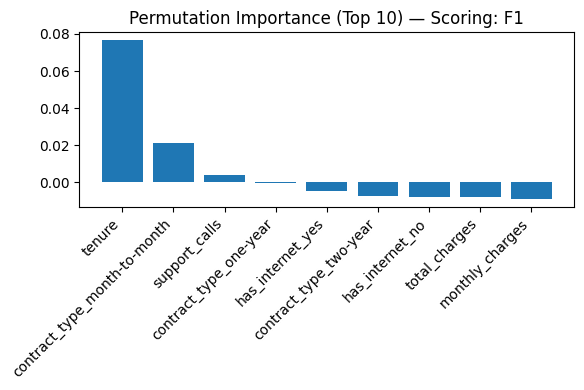

In [48]:
# 상위 10개 시각화
sorted_idx = perm.importances_mean.argsort()[::-1][:10]  # 평균 중요도 기준 내림차순 상위 10

plt.figure(figsize=(6, 4))  # 그림 크기 지정
plt.bar(range(len(sorted_idx)), perm.importances_mean[sorted_idx])  # 막대 그래프
plt.xticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx], rotation=45, ha="right")  # x축 라벨
plt.title("Permutation Importance (Top 10) — Scoring: F1")  # 제목
plt.tight_layout()  # 레이아웃 조정
plt.show()  # 출력

In [49]:
# 모델 저장/불러오기
# ============================================
joblib.dump(pipe, "churn_model_pipeline.joblib")  # 학습된 파이프라인을 파일로 저장
print("\n모델이 'churn_model_pipeline.joblib' 이름으로 저장되었습니다.")  # 저장 완료 안내

# 저장된 모델 로딩 테스트(옵션)
loaded = joblib.load("churn_model_pipeline.joblib")  # 파일에서 모델 로드
test_example = X_test.iloc[[0]]  # 테스트 샘플 1건 선택
pred_proba_example = loaded.predict_proba(test_example)[:, 1][0]  # 이탈 확률 예측
print(f"불러온 모델 테스트 — 샘플 1건 이탈 확률: {pred_proba_example:.4f}")  # 예측 결과 출력


모델이 'churn_model_pipeline.joblib' 이름으로 저장되었습니다.
불러온 모델 테스트 — 샘플 1건 이탈 확률: 0.7890


In [50]:
# eos